In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

EXAMPLES_DIR = Path.cwd().parent / "Examples"
sys.path.insert(0, str(EXAMPLES_DIR))

import functions
import plotting
import solvers

Generating ground truth with 10000 points...
  Computed 2000/10000 points...
  Computed 4000/10000 points...
  Computed 6000/10000 points...
  Computed 8000/10000 points...
  Computed 10000/10000 points...
Ground truth generation complete.


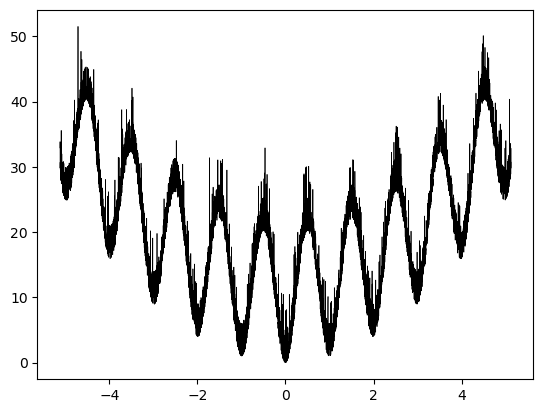

In [2]:
xm_truth, J_truth = plotting.generate_rastrigin_ground_truth(n_points=10000)

plt.plot(xm_truth, J_truth, label="Rastrigin Ground Truth", color="black", linewidth=0.5)

In [3]:
history = plotting.run_bilevel_bo_with_history(
    n_iterations=100,
    n_inner_starts=20,
    seed=44
    )

Generating 5 initial samples...
Running 100 BO iterations...
  Iteration 10/100: best_J = 4.9346
  Iteration 20/100: best_J = 1.1143
  Iteration 30/100: best_J = 0.2912
  Iteration 40/100: best_J = 0.0499
  Iteration 50/100: best_J = 0.0379
  Iteration 60/100: best_J = 0.0379
  Iteration 70/100: best_J = 0.0013
  Iteration 80/100: best_J = 0.0013


c:\Users\jhamm\anaconda3\envs\bo\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


  Iteration 90/100: best_J = 0.0013


c:\Users\jhamm\anaconda3\envs\bo\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


  Iteration 100/100: best_J = 0.0013


C:\Users\jhamm\AppData\Local\Temp\ipykernel_103472\1978480752.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


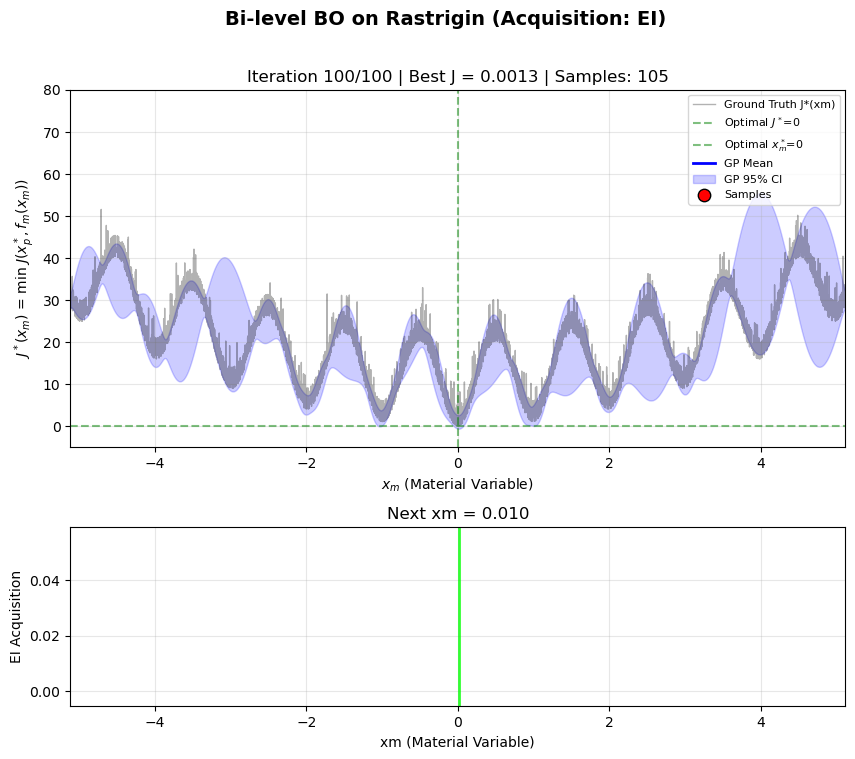

In [5]:
acquisition = history['acquisition']
problem = functions.create_rastrigin()
interval = 500  # milliseconds
n_iterations = history['n_iterations']
# ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[2, 1], gridspec_kw={'hspace': 0.3})
fig.suptitle(f'Bi-level BO on Rastrigin (Acquisition: {acquisition.upper()})',
                fontsize=14, fontweight='bold')

xm_grid = history['xm_grid']
n_frames = len(history['Xm_history'])

# Initialize plot elements
# Top subplot
ax1.plot(xm_truth, J_truth, 'k-', alpha=0.3, linewidth=1, label='Ground Truth J*(xm)')
ax1.axhline(y=0, color='green', linestyle='--', alpha=0.5, label=r'Optimal $J^*$=0')
ax1.axvline(x=0, color='green', linestyle='--', alpha=0.5, label=r'Optimal $x_m^*$=0')

gp_mean_line, = ax1.plot([], [], 'b-', linewidth=2, label='GP Mean')
gp_fill = ax1.fill_between([], [], [], alpha=0.2, color='blue', label='GP 95% CI')
sample_scatter = ax1.scatter([], [], c='red', s=80, zorder=5,
                                edgecolors='black', label='Samples')
next_point_scatter = ax1.scatter([], [], c='lime', s=150, marker='*',
                                    zorder=6, edgecolors='black', linewidths=1.5)

ax1.set_xlim(problem.xm_lower[0], problem.xm_upper[0])
ax1.set_ylim(-5, 80)
ax1.set_xlabel(r'$x_m$ (Material Variable)')
ax1.set_ylabel(r'$J^*(x_m)$ = min $J(x_p^*, f_m(x_m))$')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

title1 = ax1.set_title('')

# Bottom subplot
acq_line, = ax2.plot([], [], 'purple', linewidth=2)
next_xm_line = ax2.axvline(x=0, color='lime', linestyle='-', linewidth=2, alpha=0.8)

ax2.set_xlim(problem.xm_lower[0], problem.xm_upper[0])
ax2.set_xlabel('xm (Material Variable)')
ax2.set_ylabel(f'{acquisition.upper()} Acquisition')
ax2.grid(True, alpha=0.3)

title2 = ax2.set_title('')

plt.tight_layout()

def init():
    gp_mean_line.set_data([], [])
    acq_line.set_data([], [])
    sample_scatter.set_offsets(np.empty((0, 2)))
    next_point_scatter.set_offsets(np.empty((0, 2)))
    return gp_mean_line, acq_line, sample_scatter, next_point_scatter

def update(frame):
    # Get data for this frame
    Xm = history['Xm_history'][frame]
    Y = history['Y_history'][frame]
    gp_data = history['gp_history'][frame]
    acq_data = history['acq_history'][frame]
    next_xm = history['next_xm_history'][frame]

    n_initial = history['n_initial']

    # Update sample scatter
    sample_scatter.set_offsets(np.column_stack([Xm.flatten(), Y]))

    # Update titles
    if frame < n_initial:
        title1.set_text(f'Initial Sampling: {frame + 1}/{n_initial} points')
        title2.set_text('Acquisition function (computed after initial sampling)')
    else:
        iter_num = frame - n_initial + 1
        best_J = np.min(Y)
        title1.set_text(f'Iteration {iter_num}/{n_iterations} | Best J = {best_J:.4f} | Samples: {len(Y)}')
        title2.set_text(f'Next xm = {next_xm[0]:.3f}')

    # Clear and update GP fill
    for coll in ax1.collections:
        if coll != sample_scatter and coll != next_point_scatter:
            try:
                coll.remove()
            except (ValueError, AttributeError):
                pass

    # Update GP predictions
    if gp_data is not None:
        mu = gp_data['mu']
        sigma = gp_data['sigma']

        gp_mean_line.set_data(xm_grid, mu)
        ax1.fill_between(xm_grid, mu - 1.96*sigma, mu + 1.96*sigma,
                        alpha=0.2, color='blue')

        # Update next point marker
        next_J_pred = mu[np.argmin(np.abs(xm_grid - next_xm[0]))]
        next_point_scatter.set_offsets([[next_xm[0], next_J_pred]])
    else:
        gp_mean_line.set_data([], [])
        next_point_scatter.set_offsets(np.empty((0, 2)))

    # Update acquisition function
    if acq_data is not None:
        acq_line.set_data(xm_grid, acq_data)
        ax2.set_ylim(np.min(acq_data) - 0.1 * np.ptp(acq_data),
                    np.max(acq_data) + 0.1 * np.ptp(acq_data))
        next_xm_line.set_xdata([next_xm[0], next_xm[0]])
    else:
        acq_line.set_data([], [])

    # Re-add ground truth (since fill_between clears it)
    # This is handled by not removing the original line plot

    return gp_mean_line, acq_line, sample_scatter, next_point_scatter

anim = FuncAnimation(
    fig, update, frames=n_frames,
    init_func=init, blit=False, interval=interval, repeat=True
)

anim.save('bilevel_bo_rastrigin.gif', writer='pillow', fps=2)


In [20]:
anim.save('bilevel_bo_rastrigin.gif', writer='pillow', fps=2)